### Libraries

In [1]:
import json
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer

c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed) # Set the seed for the current GPU
    torch.cuda.manual_seed_all(seed) # Set the seed for all GPUs (if you are using multi-GPU).

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Set up Hugging Face cache directory
cache_dir = Path(r"C:/Users/User/Documents/devanasokan_fyp/huggingface_cache")
cache_dir.mkdir(parents=True, exist_ok=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", cache_dir=str(cache_dir))
print(f"Tokenizer vocab size: {len(tokenizer)}")

Tokenizer vocab size: 30522


### Setup

In [4]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/train70.csv")
val_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/val15.csv")
test_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/test15.csv")

In [5]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/train80.csv")
val_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/val10.csv")
test_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/test10.csv")

In [6]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [7]:
print("train:", train_df.shape, train_df["label"].value_counts().sort_index().to_dict())
print("val:", val_df.shape, val_df["label"].value_counts().sort_index().to_dict())
print("test:", test_df.shape, test_df["label"].value_counts().sort_index().to_dict())

train: (18302, 2) {0: 9151, 1: 9151}
val: (2288, 2) {0: 1144, 1: 1144}
test: (2288, 2) {0: 1144, 1: 1144}


In [8]:
# Determine the ratio based on the shape of the training DataFrame
if train_df.shape == (18302,2):
    ratio = "80:10:10"
else:
    ratio = "70:15:15"

In [9]:
MAX_LEN = 180


def tokenize(text: str) -> list[str]:
    return tokenizer.tokenize(text)


counter = Counter()
for text in train_df["verse"]:
    counter.update(tokenize(text))

vocab = tokenizer.get_vocab()

print(f"Vocabulary size: {len(vocab)}")
print("Most common tokens:", counter.most_common(10))

Token indices sequence length is longer than the specified maximum sequence length for this model (657 > 512). Running this sequence through the model will result in indexing errors


Vocabulary size: 30522
Most common tokens: [(',', 216322), ('i', 54906), ('you', 40629), ('the', 31056), ('to', 24273), ('it', 20227), ('a', 19852), ('me', 18337), ('and', 17799), ('not', 15771)]


In [10]:
def numericalize(text: str) -> tuple[torch.Tensor, torch.Tensor]:
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LEN,
    )
    if not token_ids:
        token_ids = [tokenizer.unk_token_id]
    length = len(token_ids)
    if len(token_ids) < MAX_LEN:
        token_ids += [tokenizer.pad_token_id] * (MAX_LEN - len(token_ids))
    return torch.tensor(token_ids, dtype=torch.long), torch.tensor(length, dtype=torch.long)

sample_ids, sample_length = numericalize(train_df.iloc[0]["verse"] )
print("sample length:", sample_length.item())
print("sample ids:", sample_ids[:20].tolist())

sample length: 61
sample ids: [2026, 1010, 2026, 1010, 2092, 1010, 2009, 2003, 25085, 2066, 2057, 2024, 2035, 2183, 2000, 3280, 1010, 2035, 2183, 2000]


In [11]:
class LyricsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["verse"].tolist()
        self.labels = frame["label"].astype(np.float32).tolist()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int):
        input_ids, length = numericalize(self.texts[index])
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return input_ids, length, label

### Hyperparameter Tuning with Optuna

We'll search for the best hyperparameters using Optuna, which efficiently explores different combinations and focuses on promising regions. We'll tune:
- Learning rate (1e-4 to 1e-3)
- Embedding dimension (64, 128, 256)
- Hidden dimension (128, 256, 512)
- Number of layers (1, 2, 3)
- Dropout rate (0.1 to 0.5)
- Batch size (16, 32, 64)

In [12]:
# Define the LSTM model
class LSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_dim: int = 128,
        num_layers: int = 2,
        bidirectional: bool = True,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, _) = self.lstm(packed)
        if self.lstm.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        logits = self.fc(self.dropout(hidden))
        return logits.squeeze(1)

In [13]:
# Run one epoch of training or evaluation
def run_epoch(model, loader: DataLoader, criterion, optimizer=None, training: bool = True):
    model.train() if training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_targets = []

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Get probability scores
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.detach().cpu().tolist())
        
        predictions = (probs >= 0.5).long()
        all_predictions.extend(predictions.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().long().tolist())
        total_loss += loss.item() * input_ids.size(0)

    average_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    return average_loss, accuracy, all_targets, all_probs, all_predictions

In [ ]:
# Modified objective function with Early Stopping (Patience=3)
# Add this to your notebook in place of the existing objective function

import optuna
from optuna.pruners import MedianPruner

def objective(trial: optuna.Trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_categorical("learning_rate", [1e-4, 5e-4, 1e-3])
    embedding_dim = trial.suggest_categorical("embedding_dim", [64, 128, 256])
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_categorical("dropout", [0.1, 0.3, 0.5])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Create data loaders with the suggested batch size
    train_loader = DataLoader(LyricsDataset(train_df), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(LyricsDataset(val_df), batch_size=batch_size, shuffle=False)

    # Initialize model with suggested hyperparameters
    model = LSTMClassifier(
        vocab_size=len(tokenizer),
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train for a few epochs with Early Stopping
    num_epochs = 10
    best_val_loss = float("inf")
    patience = 3
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, criterion, optimizer, training=True)
        val_loss, val_acc, _, _, _ = run_epoch(model, val_loader, criterion, training=False)

        print(f"  Trial {trial.number}, Epoch {epoch + 1}/{num_epochs}: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        # Early Stopping Logic (Patience = 3)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # Reset patience counter when loss improves
        else:
            patience_counter += 1  # Increment patience counter when loss doesn't improve

        # Prune trial if validation loss is not improving (MedianPruner)
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        # Early stop if patience is exceeded
        if patience_counter >= patience:
            print(f"  Early stopping triggered! No improvement for {patience} epochs.")
            break

    return best_val_loss

In [15]:
# For reproducibility, set a fixed seed for the TPE sampler
sampler = optuna.samplers.TPESampler(seed=42)

In [ ]:
# Create a study and run the hyperparameter search
study = optuna.create_study(
    direction="minimize",  # Minimize validation loss
    sampler=sampler,
    pruner=MedianPruner(),
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-08-06 13:22:09,411] A new study created in memory with name: no-name-d9fea08a-6bac-46f7-8843-9bf46020c830
  0%|          | 0/20 [00:00<?, ?it/s]

  Trial 0, Epoch 1/10: val_loss=0.6085, val_acc=0.6648
  Trial 0, Epoch 2/10: val_loss=0.5665, val_acc=0.6997
  Trial 0, Epoch 3/10: val_loss=0.4988, val_acc=0.7456
  Trial 0, Epoch 4/10: val_loss=0.5081, val_acc=0.7675
  Trial 0, Epoch 5/10: val_loss=0.4936, val_acc=0.7657
  Trial 0, Epoch 6/10: val_loss=0.4430, val_acc=0.7976
  Trial 0, Epoch 7/10: val_loss=0.4488, val_acc=0.8051
  Trial 0, Epoch 8/10: val_loss=0.4452, val_acc=0.8138
  Trial 0, Epoch 9/10: val_loss=0.4058, val_acc=0.8164


Best trial: 0. Best value: 0.40584:   5%|▌         | 1/20 [14:35<4:37:06, 875.09s/it]

  Trial 0, Epoch 10/10: val_loss=0.4187, val_acc=0.8212
[I 2026-08-06 13:36:44,500] Trial 0 finished with value: 0.4058395001021298 and parameters: {'learning_rate': 0.0005, 'embedding_dim': 64, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.3, 'batch_size': 16}. Best is trial 0 with value: 0.4058395001021298.
  Trial 1, Epoch 1/10: val_loss=0.5876, val_acc=0.6858
  Trial 1, Epoch 2/10: val_loss=0.4724, val_acc=0.7780
  Trial 1, Epoch 3/10: val_loss=0.4348, val_acc=0.7946
  Trial 1, Epoch 4/10: val_loss=0.4252, val_acc=0.8011
  Trial 1, Epoch 5/10: val_loss=0.4097, val_acc=0.8112
  Trial 1, Epoch 6/10: val_loss=0.4968, val_acc=0.8191
  Trial 1, Epoch 7/10: val_loss=0.5324, val_acc=0.8156
  Trial 1, Epoch 8/10: val_loss=0.6093, val_acc=0.8134
  Trial 1, Epoch 9/10: val_loss=0.6444, val_acc=0.8191


Best trial: 0. Best value: 0.40584:  10%|█         | 2/20 [29:42<4:28:13, 894.07s/it]

  Trial 1, Epoch 10/10: val_loss=0.7525, val_acc=0.8234
[I 2026-08-06 13:51:51,859] Trial 1 finished with value: 0.40966715387531094 and parameters: {'learning_rate': 0.0005, 'embedding_dim': 128, 'hidden_dim': 512, 'num_layers': 3, 'dropout': 0.5, 'batch_size': 32}. Best is trial 0 with value: 0.4058395001021298.
  Trial 2, Epoch 1/10: val_loss=0.5905, val_acc=0.6932
  Trial 2, Epoch 2/10: val_loss=0.5313, val_acc=0.7203


Best trial: 0. Best value: 0.40584:  10%|█         | 2/20 [31:12<4:40:51, 936.17s/it]


[W 2026-08-06 13:53:21,738] Trial 2 failed with parameters: {'learning_rate': 0.001, 'embedding_dim': 64, 'hidden_dim': 128, 'num_layers': 2, 'dropout': 0.3, 'batch_size': 16} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\User\AppData\Local\Temp\ipykernel_69988\1980323151.py", line 35, in objective
    train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, criterion, optimizer, training=True)
                                     ~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\User\AppData\Local\Temp\ipykernel_69988\799653859.py", line 10, in run_epoch
    for input_ids, lengths, labels in loader:
                                      ^^^^^^
  File "c:\Users\User\Documents\devanasokan_fyp\.venv\Lib\site-packages\torch\utils\data

KeyboardInterrupt: 

In [ ]:
# Print best trial results
best_trial = study.best_trial

print(f"Best validation loss: {best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best validation loss: 0.3952
Best hyperparameters:
  learning_rate: 0.001
  embedding_dim: 128
  hidden_dim: 256
  num_layers: 2
  dropout: 0.5
  batch_size: 16


### Final Training with Best Hyperparameters

Train the final model using the best hyperparameters found by Optuna on the full train set, and evaluate on the test set.

In [ ]:
# Extract best hyperparameters
best_params = best_trial.params
best_learning_rate = best_params["learning_rate"]
best_embedding_dim = best_params["embedding_dim"]
best_hidden_dim = best_params["hidden_dim"]
best_num_layers = best_params["num_layers"]
best_dropout = best_params["dropout"]
best_batch_size = best_params["batch_size"]

# Create data loaders with best batch size
train_loader = DataLoader(LyricsDataset(train_df), batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(LyricsDataset(val_df), batch_size=best_batch_size, shuffle=False)
test_loader = DataLoader(LyricsDataset(test_df), batch_size=best_batch_size, shuffle=False)

# Initialize final model with best hyperparameters
model = LSTMClassifier(
    vocab_size=len(tokenizer),
    embedding_dim=best_embedding_dim,
    hidden_dim=best_hidden_dim,
    num_layers=best_num_layers,
    dropout=best_dropout,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_learning_rate)

print("Final model architecture:")
print(model)

Final model architecture:
LSTMClassifier(
  (embedding): Embedding(30522, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


In [ ]:
num_epochs = 10 # Maybe change, might be overfitting, but we can use early stopping to prevent that
best_val_loss = float("inf")
best_model_path = Path("lstm_lyrics_classifier.pt")
history = []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, train_targets, train_probs, train_predictions = run_epoch(model, train_loader, criterion, optimizer, training=True)
    val_loss, val_acc, val_targets, val_probs, val_predictions = run_epoch(model, val_loader, criterion, training=False)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=0.6423 train_acc=0.6258 | val_loss=0.5437 val_acc=0.7172
Epoch 02 | train_loss=0.5063 train_acc=0.7546 | val_loss=0.4984 val_acc=0.7539
Epoch 03 | train_loss=0.3985 train_acc=0.8175 | val_loss=0.4043 val_acc=0.8173
Epoch 04 | train_loss=0.3125 train_acc=0.8652 | val_loss=0.3840 val_acc=0.8396
Epoch 05 | train_loss=0.2340 train_acc=0.9026 | val_loss=0.4292 val_acc=0.8352
Epoch 06 | train_loss=0.1701 train_acc=0.9329 | val_loss=0.4626 val_acc=0.8435
Epoch 07 | train_loss=0.1083 train_acc=0.9587 | val_loss=0.5112 val_acc=0.8470
Epoch 08 | train_loss=0.0731 train_acc=0.9733 | val_loss=0.5350 val_acc=0.8440
Epoch 09 | train_loss=0.0540 train_acc=0.9807 | val_loss=0.6222 val_acc=0.8510
Epoch 10 | train_loss=0.0420 train_acc=0.9857 | val_loss=0.7603 val_acc=0.8422


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.642301,0.625779,0.543724,0.717220
1,2,0.506293,0.754562,0.498358,0.753934
2,3,0.398477,0.817452,0.404298,0.817308
3,4,0.312498,0.865206,0.384005,0.839598
4,5,0.233969,0.902579,0.429190,0.835227
5,6,0.170146,0.932904,0.462638,0.843531
6,7,0.108335,0.958693,0.511173,0.847028
7,8,0.073085,0.973282,0.535006,0.843969
8,9,0.053975,0.980712,0.622218,0.850962
9,10,0.042035,0.985685,0.760333,0.842220


### Model Evaluation

In [ ]:
# Load best checkpoint and evaluate on test
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc, test_targets, test_probs, test_predictions = run_epoch(model, test_loader, criterion, training=False)

#### Classification Report

In [ ]:
report = classification_report(
    test_targets,
    test_predictions,
    output_dict=True
)

accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"LSTM CLASSIFICATION REPORT (TUNING - {ratio}):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

LSTM CLASSIFICATION REPORT (TUNING - 80:10:10):
Accuracy: 0.8221153846153846
Precision: 0.8287243532560215
Recall: 0.8120629370629371
F1-score: 0.820309050772627


#### ROC-AUC Curve

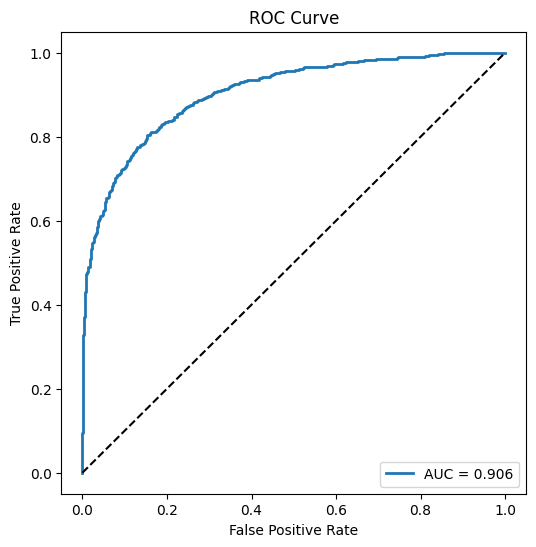

In [ ]:
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.9153043292386368


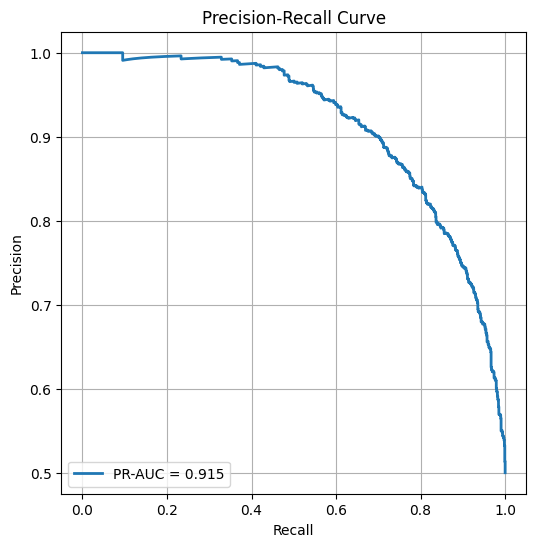

In [ ]:
precision, recall, thresholds = precision_recall_curve(
    test_targets,
    test_probs
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

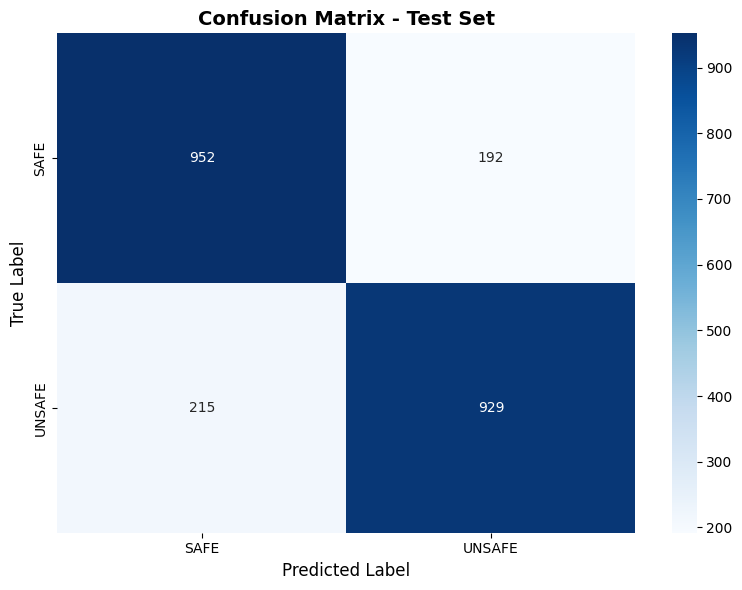

In [ ]:
# Confusion matrix
cm = pd.crosstab(pd.Series(test_targets, name="Actual"), pd.Series(test_predictions, name="Predicted"))

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
artifact_dir = Path("lstm_artifacts")
artifact_dir.mkdir(exist_ok=True)

model_path = artifact_dir / "lyrics_lstm.pt"
vocab_path = artifact_dir / "lyrics_vocab.json"
params_path = artifact_dir / "best_hyperparams.json"

torch.save(model.state_dict(), model_path)
with open(vocab_path, "w", encoding="utf-8") as vocab_file:
    json.dump(vocab, vocab_file, ensure_ascii=False, indent=2)
with open(params_path, "w", encoding="utf-8") as params_file:
    json.dump(best_params, params_file, indent=2)

print("Artifacts saved:")
print(f"  Model: {model_path}")
print(f"  Vocab: {vocab_path}")
print(f"  Best hyperparameters: {params_path}")

Artifacts saved:
  Model: lstm_artifacts\lyrics_lstm.pt
  Vocab: lstm_artifacts\lyrics_vocab.json
  Best hyperparameters: lstm_artifacts\best_hyperparams.json


In [ ]:
def predict_text(text: str):
    model.eval()
    input_ids, length = numericalize(text)
    with torch.no_grad():
        logits = model(input_ids.unsqueeze(0).to(device), length.unsqueeze(0).to(device))
        probability = torch.sigmoid(logits).item()
        prediction = int(probability >= 0.5)
    return probability, prediction


sample_probability, sample_prediction = predict_text("you in the dark")
print({"probability": sample_probability, "prediction": sample_prediction})

{'probability': 0.10422634333372116, 'prediction': 0}
